# Superstore Sales Analysis
## Notebook 04: Regional Analysis

### Objective
This notebook analyzes sales and profit performance across 
different geographic dimensions including regions, states, 
and cities.

### Business Questions
1. Which region generates the highest sales and profit?
2. Which region has the best profit margin?
3. What are the Top 10 states by sales?
4. Which states are generating losses?
5. What are the Top 10 cities by sales?
6. How is profitability distributed geographically?

In [1]:
# IMPORT LIBRARIES 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create folders if not exist
os.makedirs('images', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# LOAD CLEANED DATA 

df = pd.read_csv('data/processed/superstore_cleaned.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print("Data loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully
Shape: (9994, 27)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Profit Margin (%),Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,Nov,4,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,Nov,4,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,Jun,2,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,Oct,4,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,Oct,4,11.25,7


In [3]:
# HELPER FUNCTIONS 

def format_currency(value):
    return f"${value:,.2f}"

def format_percent(value):
    return f"{value:.2f}%"

def save_fig(filename):
    plt.savefig(f'images/{filename}', dpi=150, bbox_inches='tight')
    print(f"✅ Saved: images/{filename}")

print("Helper functions ready")

Helper functions ready


## 1. Sales and Profit by Region

Business question:

**Which region generates the highest sales and profit?**

In [4]:
# REGION PERFORMANCE

region_performance = df.groupby('Region').agg(
    Total_Sales    = ('Sales',       'sum'),
    Total_Profit   = ('Profit',      'sum'),
    Total_Orders   = ('Order ID',    'nunique'),
    Total_Customers= ('Customer ID', 'nunique'),
    Total_Quantity = ('Quantity',    'sum'),
    Avg_Discount   = ('Discount',    'mean')
).reset_index()

# Profit Margin
region_performance['Profit_Margin_%'] = (
    region_performance['Total_Profit'] /
    region_performance['Total_Sales'] * 100
).round(2)

# Sales Share
region_performance['Sales_Share_%'] = (
    region_performance['Total_Sales'] /
    region_performance['Total_Sales'].sum() * 100
).round(2)

# Avg Discount %
region_performance['Avg_Discount_%'] = (
    region_performance['Avg_Discount'] * 100
).round(2)

# Sort by Total Sales
region_performance = region_performance.sort_values(
    'Total_Sales', ascending=False
).reset_index(drop=True)

region_performance

,Region,Total_Sales,Total_Profit,Total_Orders,Total_Customers,Total_Quantity,Avg_Discount,Profit_Margin_%,Sales_Share_%,Avg_Discount_%
0,West,725457.82,108418.45,1611,686,12266,0.11,14.94,31.58,10.93
1,East,678781.24,91522.78,1401,674,10618,0.15,13.48,29.55,14.54
2,Central,501239.89,39706.36,1175,629,8780,0.24,7.92,21.82,24.04
3,South,391721.91,46749.43,822,512,6209,0.15,11.93,17.05,14.73


In [5]:
# PRINT REGION SUMMARY

print("=" * 60)
print("REGIONAL PERFORMANCE SUMMARY")
print("=" * 60)

for _, row in region_performance.iterrows():
    print(f"\nRegion: {row['Region']}")
    print(f"  Total Sales:     {format_currency(row['Total_Sales'])}")
    print(f"  Total Profit:    {format_currency(row['Total_Profit'])}")
    print(f"  Profit Margin:   {format_percent(row['Profit_Margin_%'])}")
    print(f"  Sales Share:     {format_percent(row['Sales_Share_%'])}")
    print(f"  Total Orders:    {row['Total_Orders']:,}")
    print(f"  Total Customers: {row['Total_Customers']:,}")
    print(f"  Avg Discount:    {format_percent(row['Avg_Discount_%'])}")

REGIONAL PERFORMANCE SUMMARY

Region: West
  Total Sales:     $725,457.82
  Total Profit:    $108,418.45
  Profit Margin:   14.94%
  Sales Share:     31.58%
  Total Orders:    1,611
  Total Customers: 686
  Avg Discount:    10.93%

Region: East
  Total Sales:     $678,781.24
  Total Profit:    $91,522.78
  Profit Margin:   13.48%
  Sales Share:     29.55%
  Total Orders:    1,401
  Total Customers: 674
  Avg Discount:    14.54%

Region: Central
  Total Sales:     $501,239.89
  Total Profit:    $39,706.36
  Profit Margin:   7.92%
  Sales Share:     21.82%
  Total Orders:    1,175
  Total Customers: 629
  Avg Discount:    24.04%

Region: South
  Total Sales:     $391,721.91
  Total Profit:    $46,749.43
  Profit Margin:   11.93%
  Sales Share:     17.05%
  Total Orders:    822
  Total Customers: 512
  Avg Discount:    14.73%


✅ Saved: images/region_sales_profit.png


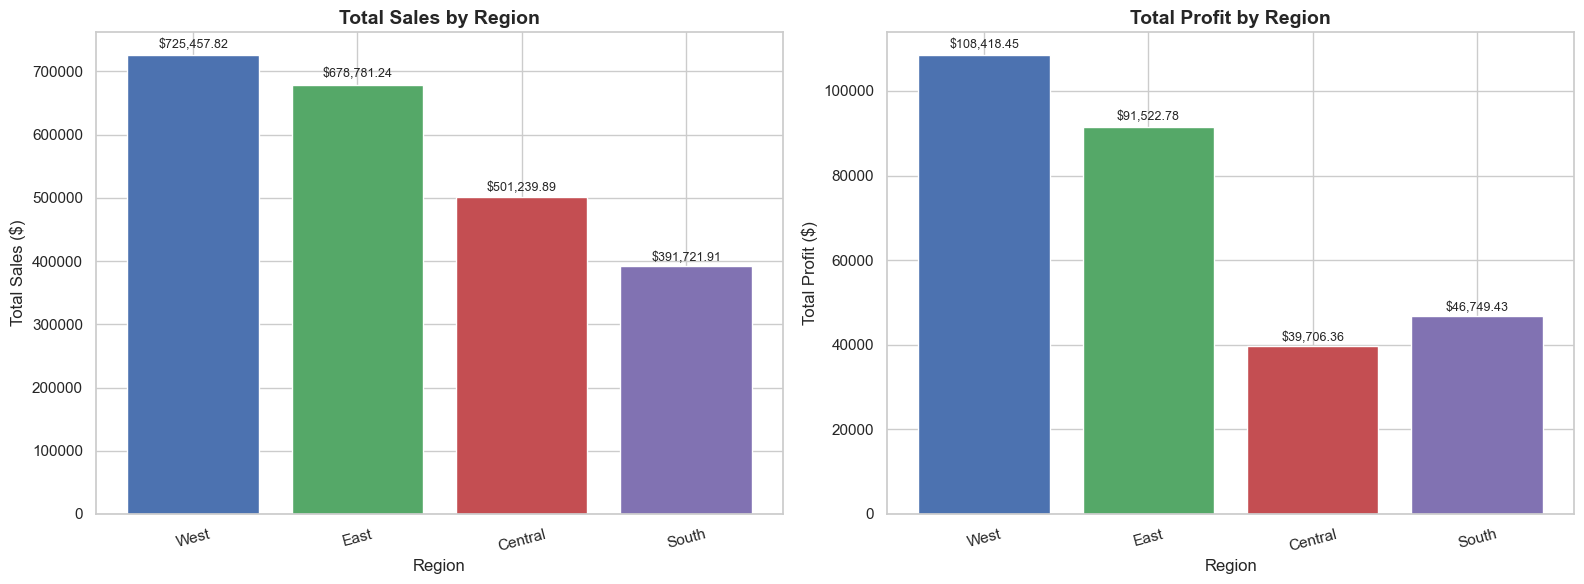

In [6]:
# VISUALIZE SALES AND PROFIT BY REGION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Sales by Region ---
bars1 = axes[0].bar(
    region_performance['Region'],
    region_performance['Total_Sales'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='white'
)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        format_currency(height),
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Total Sales by Region',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=15)

# --- Profit by Region ---
bars2 = axes[1].bar(
    region_performance['Region'],
    region_performance['Total_Profit'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='white'
)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        format_currency(height),
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title('Total Profit by Region',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('region_sales_profit.png')
plt.show()

✅ Saved: images/region_profit_margin.png


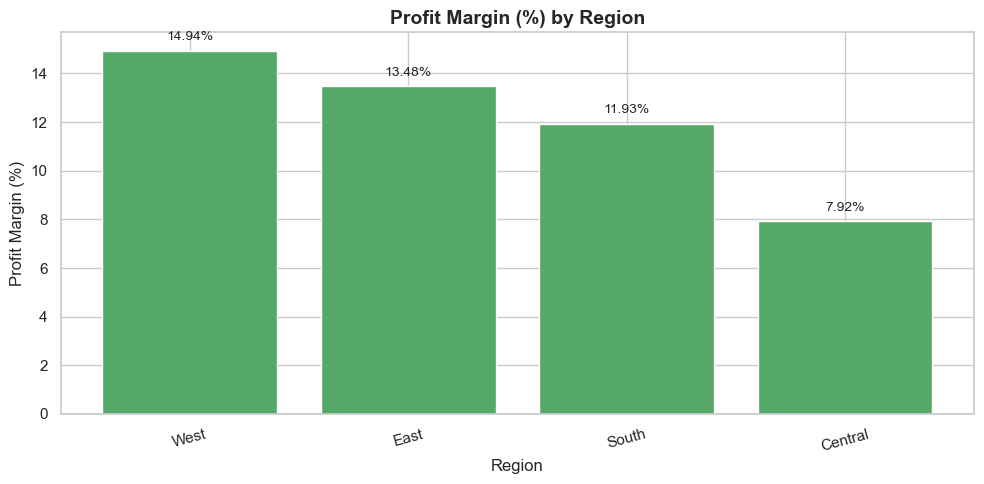

In [7]:
# PROFIT MARGIN BY REGION

region_margin_sorted = region_performance.sort_values(
    'Profit_Margin_%', ascending=False
)

colors = [
    '#55A868' if m > 0 else '#C44E52'
    for m in region_margin_sorted['Profit_Margin_%']
]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    region_margin_sorted['Region'],
    region_margin_sorted['Profit_Margin_%'],
    color=colors,
    edgecolor='white'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        format_percent(height),
        ha='center', va='bottom', fontsize=10
    )

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Profit Margin (%) by Region',
          fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')
plt.tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('region_profit_margin.png')
plt.show()

✅ Saved: images/region_sales_share_pie.png


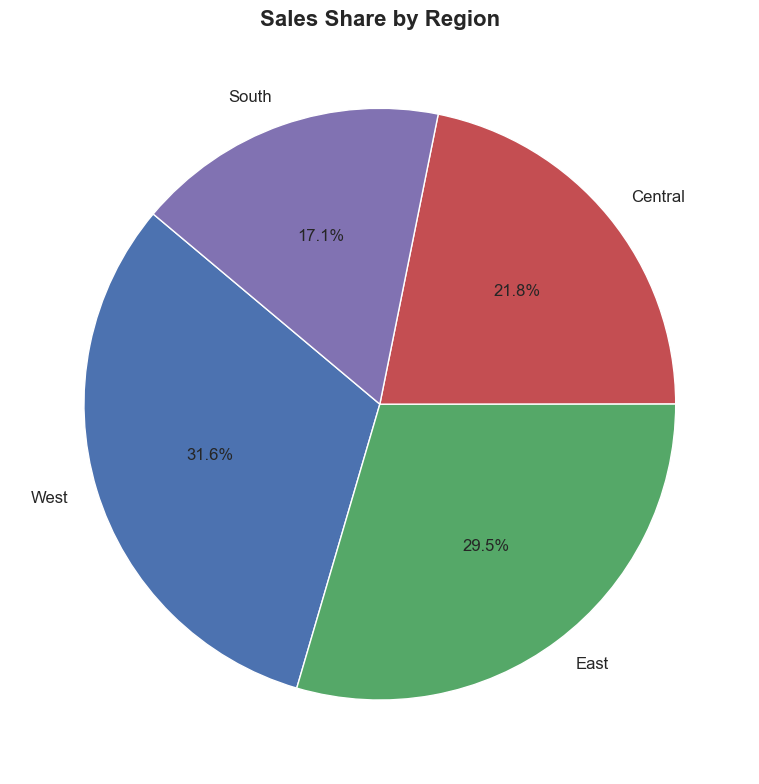

In [8]:
# SALES SHARE PIE CHART

plt.figure(figsize=(8, 8))

plt.pie(
    region_performance['Total_Sales'],
    labels=region_performance['Region'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Sales Share by Region',
          fontsize=16, fontweight='bold')

plt.tight_layout()
save_fig('region_sales_share_pie.png')
plt.show()

In [9]:
region_performance.to_csv(
    'reports/tables/region_performance.csv', index=False
)

print("Region performance table saved")

Region performance table saved


In [ ]:
### Insight



### Recommendation



## 2. State-Level Analysis

Business questions:

- **What are the Top 10 states by sales?**
- **Which states are generating losses?**

In [10]:
# STATE PERFORMANCE

state_performance = df.groupby(['Region', 'State']).agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Discount   = ('Discount', 'mean')
).reset_index()

# Profit Margin
state_performance['Profit_Margin_%'] = (
    state_performance['Total_Profit'] /
    state_performance['Total_Sales'] * 100
).round(2)

# Avg Discount %
state_performance['Avg_Discount_%'] = (
    state_performance['Avg_Discount'] * 100
).round(2)

# Sort by Total Sales
state_performance = state_performance.sort_values(
    'Total_Sales', ascending=False
).reset_index(drop=True)

print(f"Total states in dataset: {len(state_performance)}")
state_performance.head(10)

Total states in dataset: 49


,Region,State,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Avg_Discount,Profit_Margin_%,Avg_Discount_%
0,West,California,457687.63,76381.39,1021,7667,0.07,16.69,7.28
1,East,New York,310876.27,74038.55,562,4224,0.06,23.82,5.53
2,Central,Texas,170188.05,-25729.36,487,3724,0.37,-15.12,37.02
3,West,Washington,138641.27,33402.65,256,1883,0.06,24.09,6.40
4,East,Pennsylvania,116511.91,-15559.96,288,2153,0.33,-13.35,32.86
5,South,Florida,89473.71,-3399.30,200,1379,0.30,-3.80,29.93
6,Central,Illinois,80166.10,-12607.89,276,1845,0.39,-15.73,39.00
7,East,Ohio,78258.14,-16971.38,236,1759,0.32,-21.69,32.49
8,Central,Michigan,76269.61,24463.19,117,946,0.01,32.07,0.71
9,South,Virginia,70636.72,18597.95,115,893,0.00,26.33,0.00


✅ Saved: images/top10_states_by_sales.png


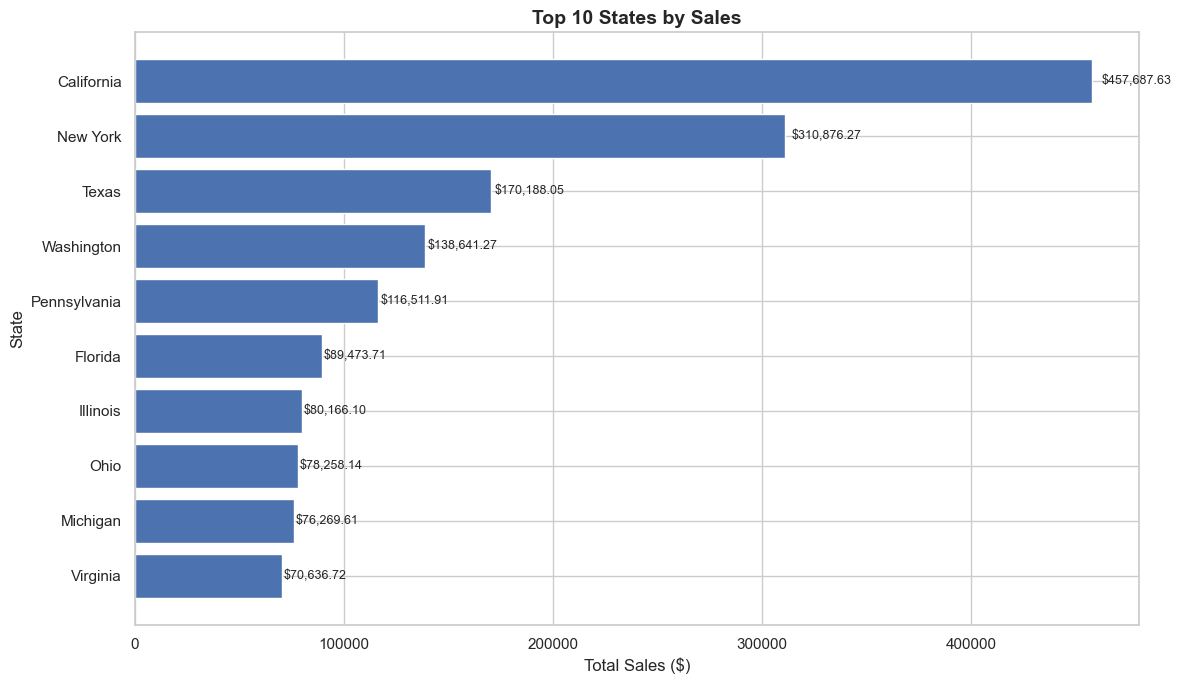

In [11]:
# TOP 10 STATES BY SALES

top10_states_sales = state_performance.head(10)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_states_sales['State'],
    top10_states_sales['Total_Sales'],
    color='#4C72B0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 States by Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('State')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_states_by_sales.png')
plt.show()

✅ Saved: images/top10_states_by_profit.png


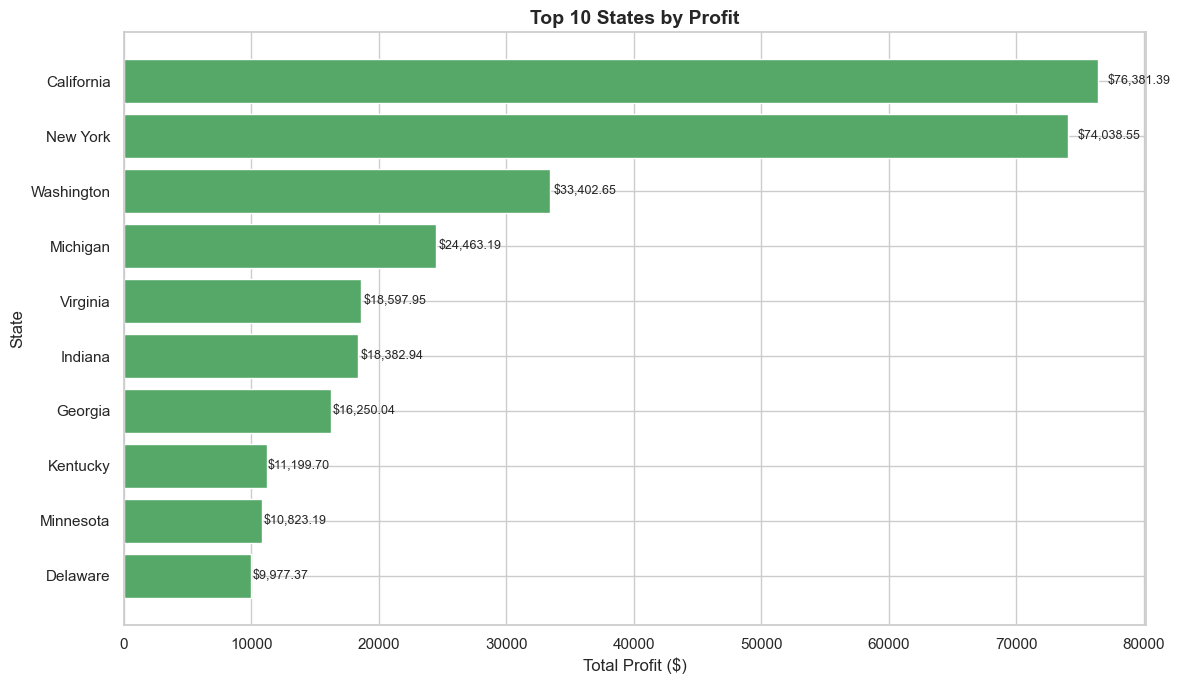

In [12]:
# TOP 10 STATES BY PROFIT 

top10_states_profit = state_performance.sort_values(
    'Total_Profit', ascending=False
).head(10)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_states_profit['State'],
    top10_states_profit['Total_Profit'],
    color='#55A868',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 States by Profit',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('State')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_states_by_profit.png')
plt.show()

In [13]:
# LOSS-MAKING STATES

loss_states = state_performance[
    state_performance['Total_Profit'] < 0
].sort_values('Total_Profit')

print("=" * 60)
print("LOSS-MAKING STATES")
print("=" * 60)
print(f"Total states with negative profit: {len(loss_states)}")
print()

for _, row in loss_states.iterrows():
    print(f"State:         {row['State']}")
    print(f"  Region:      {row['Region']}")
    print(f"  Sales:       {format_currency(row['Total_Sales'])}")
    print(f"  Profit:      {format_currency(row['Total_Profit'])}")
    print(f"  Margin:      {format_percent(row['Profit_Margin_%'])}")
    print(f"  Avg Discount:{format_percent(row['Avg_Discount_%'])}")
    print()

LOSS-MAKING STATES
Total states with negative profit: 10

State:         Texas
  Region:      Central
  Sales:       $170,188.05
  Profit:      $-25,729.36
  Margin:      -15.12%
  Avg Discount:37.02%

State:         Ohio
  Region:      East
  Sales:       $78,258.14
  Profit:      $-16,971.38
  Margin:      -21.69%
  Avg Discount:32.49%

State:         Pennsylvania
  Region:      East
  Sales:       $116,511.91
  Profit:      $-15,559.96
  Margin:      -13.35%
  Avg Discount:32.86%

State:         Illinois
  Region:      Central
  Sales:       $80,166.10
  Profit:      $-12,607.89
  Margin:      -15.73%
  Avg Discount:39.00%

State:         North Carolina
  Region:      South
  Sales:       $55,603.16
  Profit:      $-7,490.91
  Margin:      -13.47%
  Avg Discount:28.35%

State:         Colorado
  Region:      West
  Sales:       $32,108.12
  Profit:      $-6,527.86
  Margin:      -20.33%
  Avg Discount:31.65%

State:         Tennessee
  Region:      South
  Sales:       $30,661.87
  

✅ Saved: images/loss_making_states.png


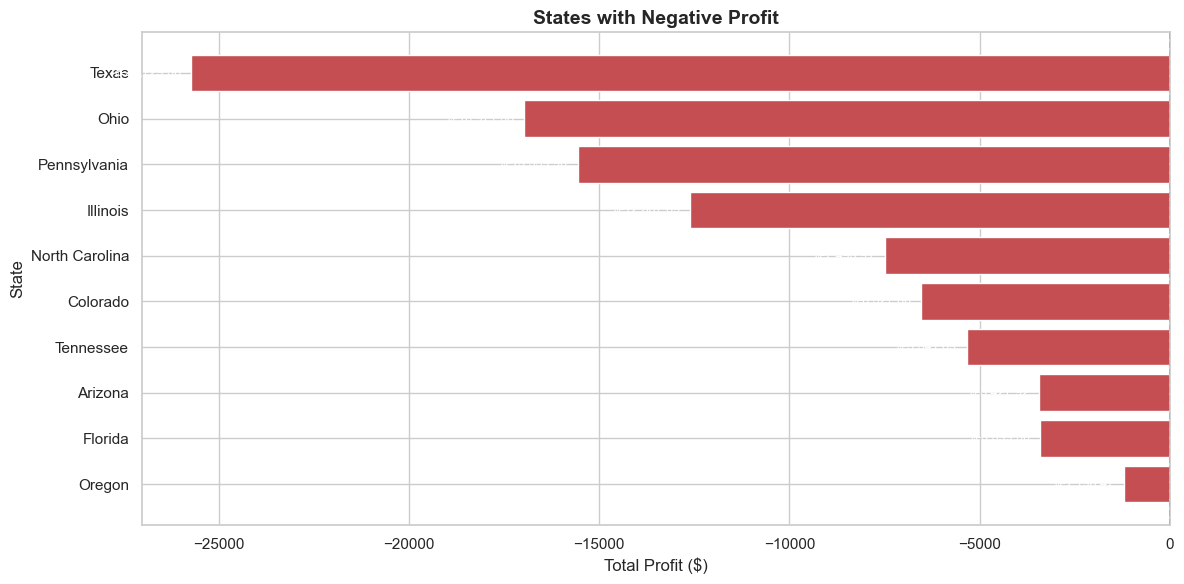

In [14]:
# VISUALIZE LOSS-MAKING STATES

if len(loss_states) > 0:
    plt.figure(figsize=(12, max(6, len(loss_states) * 0.6)))

    bars = plt.barh(
        loss_states['State'],
        loss_states['Total_Profit'],
        color='#C44E52',
        edgecolor='white'
    )

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - (abs(loss_states['Total_Profit'].min()) * 0.01),
            bar.get_y() + bar.get_height() / 2,
            format_currency(width),
            va='center', ha='right',
            fontsize=9, color='white'
        )

    plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
    plt.title('States with Negative Profit',
              fontsize=14, fontweight='bold')
    plt.xlabel('Total Profit ($)')
    plt.ylabel('State')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    save_fig('loss_making_states.png')
    plt.show()

else:
    print("No loss-making states found!")

In [15]:
# Save all state tables
state_performance.to_csv(
    'reports/tables/state_performance.csv', index=False
)

loss_states.to_csv(
    'reports/tables/loss_making_states.csv', index=False
)

print("State performance tables saved")

State performance tables saved


### Insight



### Recommendation



## 3. City-Level Analysis

Business question:

**Which cities are the top revenue generators?**

In [16]:
# CITY PERFORMANCE

city_performance = df.groupby(['State', 'City']).agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Total_Orders  = ('Order ID', 'nunique'),
    Total_Quantity= ('Quantity', 'sum')
).reset_index()

# Profit Margin
city_performance['Profit_Margin_%'] = (
    city_performance['Total_Profit'] /
    city_performance['Total_Sales'] * 100
).round(2)

# Sort
city_performance = city_performance.sort_values(
    'Total_Sales', ascending=False
).reset_index(drop=True)

print(f"Total cities in dataset: {len(city_performance)}")
city_performance.head(10)

Total cities in dataset: 604


,State,City,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
0,New York,New York City,256368.16,62036.98,450,3417,24.20
1,California,Los Angeles,175851.34,30440.76,384,2879,17.31
2,Washington,Seattle,119540.74,29156.10,212,1590,24.39
3,California,San Francisco,112669.09,17507.39,265,1935,15.54
4,Pennsylvania,Philadelphia,109077.01,-13837.77,265,1981,-12.69
5,Texas,Houston,64504.76,-10153.55,188,1466,-15.74
6,Illinois,Chicago,48539.54,-6654.57,171,1132,-13.71
7,California,San Diego,47521.03,6377.20,88,670,13.42
8,Michigan,Detroit,42446.94,13181.79,53,441,31.05
9,Florida,Jacksonville,39133.33,-2445.66,38,248,-6.25


✅ Saved: images/top10_cities_by_sales.png


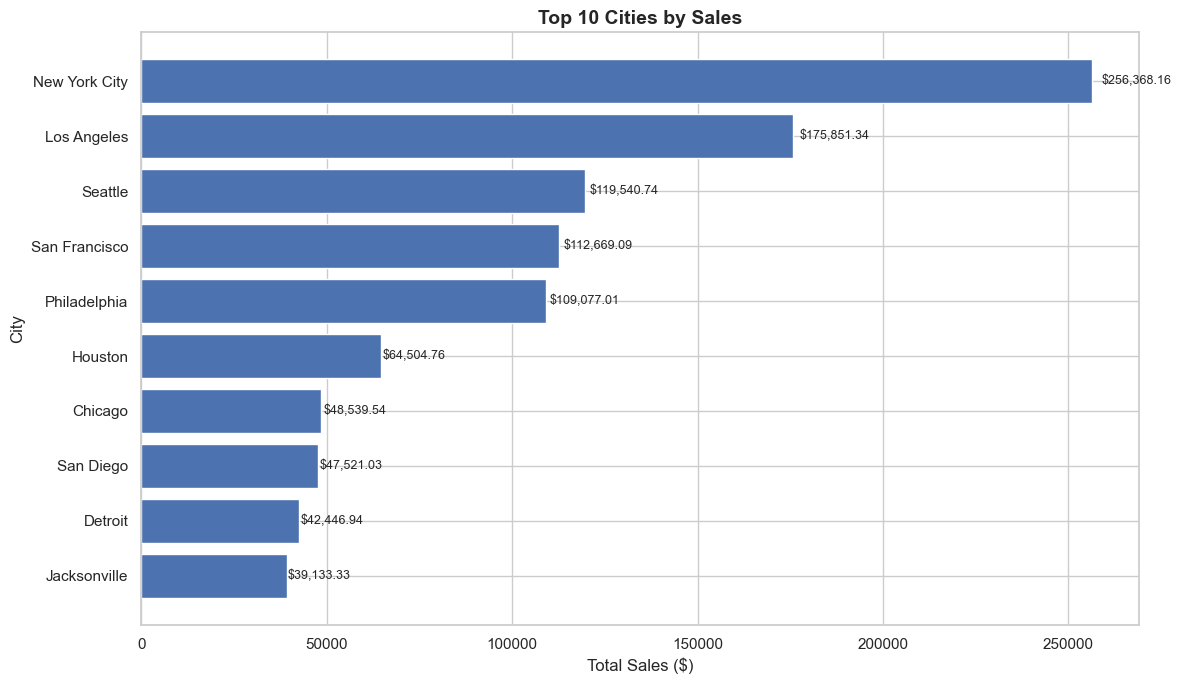

In [17]:
# TOP 10 CITIES BY SALES

top10_cities_sales = city_performance.head(10)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_cities_sales['City'],
    top10_cities_sales['Total_Sales'],
    color='#4C72B0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 Cities by Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('City')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_cities_by_sales.png')
plt.show()

✅ Saved: images/top10_cities_by_profit.png


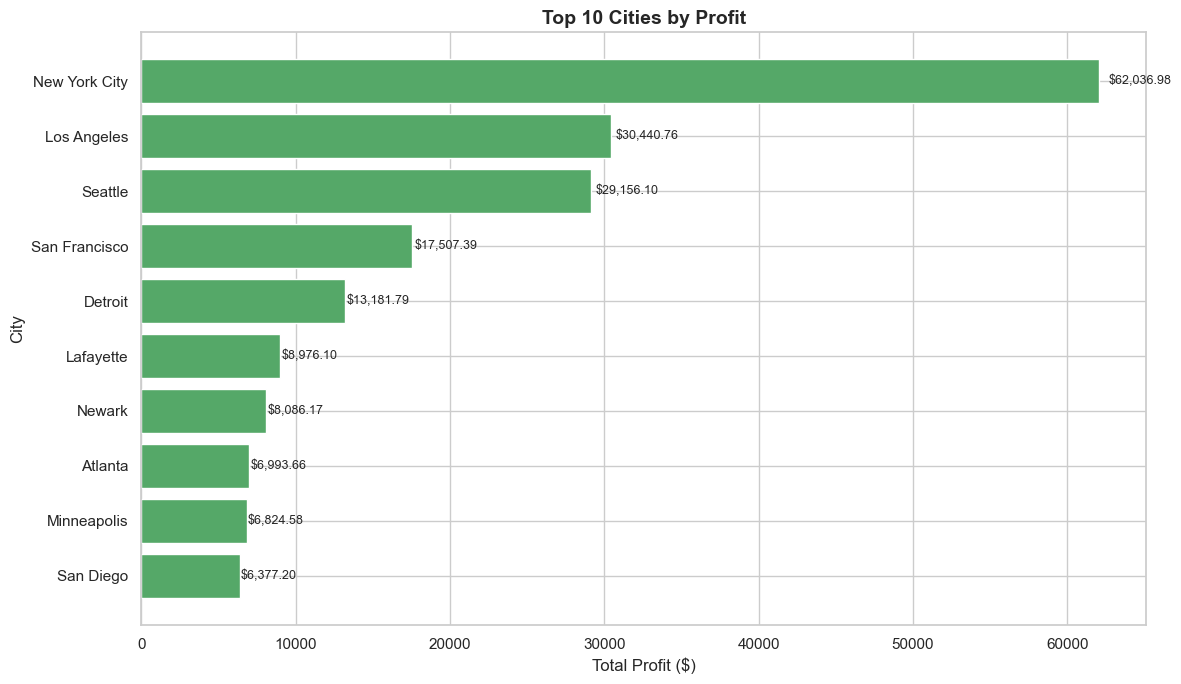

In [18]:
# TOP 10 CITIES BY PROFIT 

top10_cities_profit = city_performance.sort_values(
    'Total_Profit', ascending=False
).head(10)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_cities_profit['City'],
    top10_cities_profit['Total_Profit'],
    color='#55A868',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 Cities by Profit',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('City')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_cities_by_profit.png')
plt.show()

In [19]:
city_performance.to_csv(
    'reports/tables/city_performance.csv', index=False
)

print("City performance table saved")

City performance table saved


In [ ]:
### Insight


### Recommendation



## 4. Regional Performance by Category

Business question:

**Which category performs best in each region?**

In [20]:
# REGION x CATEGORY PERFORMANCE

region_category = df.groupby(['Region', 'Category']).agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

region_category['Profit_Margin_%'] = (
    region_category['Total_Profit'] /
    region_category['Total_Sales'] * 100
).round(2)

region_category

,Region,Category,Total_Sales,Total_Profit,Profit_Margin_%
0,Central,Furniture,163797.16,-2871.05,-1.75
1,Central,Office Supplies,167026.42,8879.98,5.32
2,Central,Technology,170416.31,33697.43,19.77
3,East,Furniture,208291.20,3046.17,1.46
4,East,Office Supplies,205516.05,41014.58,19.96
5,East,Technology,264973.98,47462.04,17.91
6,South,Furniture,117298.68,6771.21,5.77
7,South,Office Supplies,125651.31,19986.39,15.91
8,South,Technology,148771.91,19991.83,13.44
9,West,Furniture,252612.74,11504.95,4.55


✅ Saved: images/region_category_performance.png


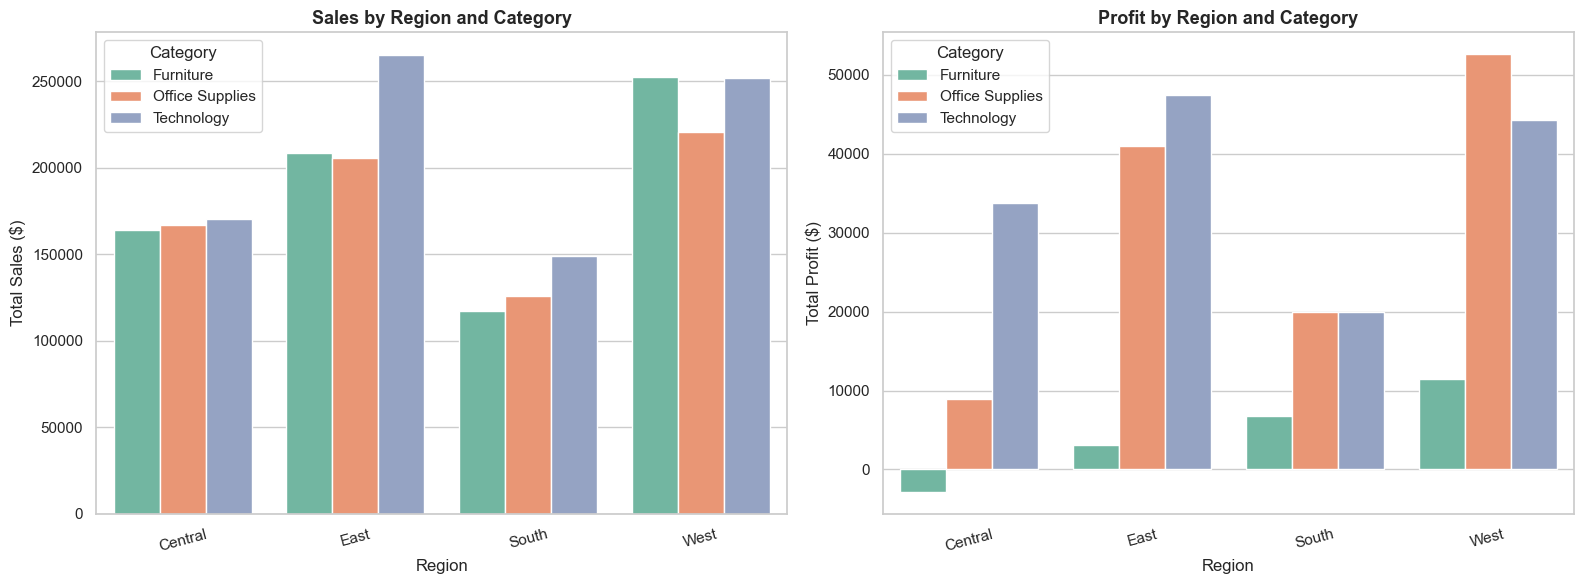

In [21]:
# VISUALIZE REGION x CATEGORY
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales
sns.barplot(
    data=region_category,
    x='Region',
    y='Total_Sales',
    hue='Category',
    ax=axes[0],
    palette='Set2'
)

axes[0].set_title('Sales by Region and Category',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Category')

# Profit
sns.barplot(
    data=region_category,
    x='Region',
    y='Total_Profit',
    hue='Category',
    ax=axes[1],
    palette='Set2'
)

axes[1].set_title('Profit by Region and Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Category')

plt.tight_layout()
save_fig('region_category_performance.png')
plt.show()

In [22]:
region_category.to_csv(
    'reports/tables/region_category_performance.csv', index=False
)

print("Region x Category table saved")

Region x Category table saved


In [ ]:
### Insight



### Recommendation



## 5. Final Summary

In [23]:
# ===== FINAL SUMMARY =====

best_region_sales  = region_performance.iloc[0]
best_region_profit = region_performance.sort_values(
    'Total_Profit', ascending=False).iloc[0]
best_region_margin = region_performance.sort_values(
    'Profit_Margin_%', ascending=False).iloc[0]

best_state_sales  = state_performance.iloc[0]
best_state_profit = state_performance.sort_values(
    'Total_Profit', ascending=False).iloc[0]

best_city_sales   = city_performance.iloc[0]

print("=" * 60)
print("REGIONAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n🌍 REGION")
print(f"  Highest Sales:   {best_region_sales['Region']} "
      f"({format_currency(best_region_sales['Total_Sales'])})")
print(f"  Highest Profit:  {best_region_profit['Region']} "
      f"({format_currency(best_region_profit['Total_Profit'])})")
print(f"  Best Margin:     {best_region_margin['Region']} "
      f"({format_percent(best_region_margin['Profit_Margin_%'])})")

print(f"\n🗺️ STATE")
print(f"  Top by Sales:    {best_state_sales['State']} "
      f"({format_currency(best_state_sales['Total_Sales'])})")
print(f"  Top by Profit:   {best_state_profit['State']} "
      f"({format_currency(best_state_profit['Total_Profit'])})")
print(f"  Loss-making states: {len(loss_states)}")

print(f"\n🏙️ CITY")
print(f"  Top by Sales:    {best_city_sales['City']} "
      f"({format_currency(best_city_sales['Total_Sales'])})")


REGIONAL ANALYSIS SUMMARY

🌍 REGION
  Highest Sales:   West ($725,457.82)
  Highest Profit:  West ($108,418.45)
  Best Margin:     West (14.94%)

🗺️ STATE
  Top by Sales:    California ($457,687.63)
  Top by Profit:   California ($76,381.39)
  Loss-making states: 10

🏙️ CITY
  Top by Sales:    New York City ($256,368.16)


## Summary

In this notebook, we analyzed geographic performance 
across regions, states, and cities.

### Key Areas Covered
- Regional sales and profit overview
- Regional profit margin comparison
- Top 10 states by sales and profit
- Loss-making states identification
- Top 10 cities by sales and profit
- Regional performance broken down by category

### Main Takeaways
- Geographic performance is not evenly distributed.
- Some states generate high sales but negative profit, 
  requiring immediate attention on discount 
  and pricing policies.
- City-level analysis provides actionable insights 
  for targeted sales and marketing strategies.

### Next Step
Notebook 05 will focus on **Customer Analysis**, including:
- Sales and profit by customer segment
- Top customers by revenue
- Customer order behavior
- Customer contribution analysis